In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
from PIL import Image
import tensorflow as tf
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix,
    precision_recall_curve
)

I0000 00:00:1783523627.683213   10670 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1783523628.052206   10670 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783523630.234525   10670 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [4]:
# -----------------------------
# paths
# -----------------------------
REPO_ROOT = Path("../..").resolve()

MANIFEST_PATH = (
    REPO_ROOT
    / "reports"
    / "manifests"
    / "broach_dataset_split_seed42.csv"
)

DATA_ROOT = REPO_ROOT / "data/03_broach_dataset"
TEST_DIR = DATA_ROOT / "test"

IMAGE_SIZE = (150, 100)

# outputs
OUTPUT_DIR = REPO_ROOT / "reports"
OUTPUT_DIR.mkdir(exist_ok=True)

MODEL_PATH = REPO_ROOT / "models/ae_bn16_ma_dataset_20260618.keras"


SCORES_PATH = OUTPUT_DIR / "ae_scores.csv"
THRESHOLD_PATH = OUTPUT_DIR / "ae_threshold.json"
METRICS_PATH = OUTPUT_DIR / "ae_metrics.csv"

val_df = pd.read_csv(OUTPUT_DIR / "val_scores_with_baselines.csv")
test_df = pd.read_csv(OUTPUT_DIR / "test_scores_with_baselines.csv")

In [5]:
def load_data_from_manifest(
    data_root: Path,
    manifest_csv: Path,
    split: str,
    target_size=(150, 100)
):
    df = pd.read_csv(manifest_csv)
    df_split = df[df["split"] == split].reset_index(drop=True)

    images, labels, filenames = [], [], []

    for _, row in tqdm(df_split.iterrows(), total=len(df_split)):
        filename = str(row["filename"])
        label = int(row["label"])

        folder = data_root / (
            "test" if split in ["test", "validation"] else "train"
        )

        file_path = folder / filename

        if not file_path.exists():
            print(f"Missing: {file_path}")
            continue

        img = (
            Image.open(file_path)
            .convert("RGB")
            .resize(target_size)
        )

        img = np.asarray(img, dtype=np.float32) / 255.0

        images.append(img)
        labels.append(label)
        filenames.append(filename)

    return (
        np.array(images),
        np.array(labels),
        np.array(filenames)
    )

## Load data and reconstruct images 

In [8]:
model = tf.keras.models.load_model(MODEL_PATH)

X_val, y_val, f_val = load_data_from_manifest(
    DATA_ROOT,
    MANIFEST_PATH,
    "validation",
    IMAGE_SIZE
)

X_test, y_test, f_test = load_data_from_manifest(
    DATA_ROOT,
    MANIFEST_PATH,
    "test",
    IMAGE_SIZE
)

E0000 00:00:1783525132.044941   10670 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
100%|██████████| 2500/2500 [00:24<00:00, 104.14it/s]


## Generate Error maps 

In [9]:
def compute_error_maps(model, images):
    recon = model.predict(images, batch_size=32, verbose=0)
    return (images - recon) ** 2


print("Computing error maps...")
val_error = compute_error_maps(model, X_val)
test_error = compute_error_maps(model, X_test)

Computing error maps...


## VER flexible 


In [10]:
def compute_ver_scores(error_map, n_segments, top_k):

    width = error_map.shape[2]
    boundaries = np.linspace(0, width, n_segments + 1, dtype=int)

    segments = []
    for l, r in zip(boundaries[:-1], boundaries[1:]):
        if r <= l:
            continue
        segments.append(
            error_map[:, :, l:r, :].mean(axis=(1,2,3))
        )

    segments = np.stack(segments, axis=1)

    ver_max = segments.max(axis=1)

    top_k = min(top_k, segments.shape[1])
    ver_topk = np.sort(segments, axis=1)[:, -top_k:].mean(axis=1)

    return ver_max, ver_topk

### Threshold a& Evaluation function 


In [11]:
def select_best_f1_threshold(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)

    if len(thresholds) == 0:
        return float(np.max(scores))

    f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
    best_idx = int(np.nanargmax(f1))

    return float(thresholds[best_idx])


def evaluate(y_true, scores, threshold):

    y_pred = (scores >= threshold).astype(int)

    return {
        "pr_auc": average_precision_score(y_true, scores),
        "f1": f1_score(y_true, y_pred)
    }


## Sensitivity Grid 


In [36]:
segment_list = list(range(1, 40))
topk_list = [1, 3, 5,10]

results = []

for n_segments in segment_list:
    for top_k in topk_list:

        # --- Scores berechnen
        val_scores, _ = compute_ver_scores(val_error, n_segments, top_k)
        test_scores, _ = compute_ver_scores(test_error, n_segments, top_k)

        # --- Threshold auf Validation
        threshold = select_best_f1_threshold(y_val, val_scores)

        # --- Evaluation auf Test
        metrics = evaluate(y_test, test_scores, threshold)

        results.append({
            "segments": n_segments,
            "top_k": top_k,
            "threshold": threshold,
            "pr_auc": metrics["pr_auc"],
            "f1": metrics["f1"]
        })


In [37]:
results_df = pd.DataFrame(results)
results_df.sort_values("pr_auc", ascending=False)

,segments,top_k,threshold,pr_auc,f1
32,9,1,0.003399,0.991982,0.871795
33,9,3,0.003399,0.991982,0.871795
34,9,5,0.003399,0.991982,0.871795
35,9,10,0.003399,0.991982,0.871795
20,6,1,0.002629,0.991982,0.871795
...,...,...,...,...,...
151,38,10,0.010482,0.579390,0.571429
152,39,1,0.010864,0.511805,0.516129
153,39,3,0.010864,0.511805,0.516129
154,39,5,0.010864,0.511805,0.516129


### PLot Results 

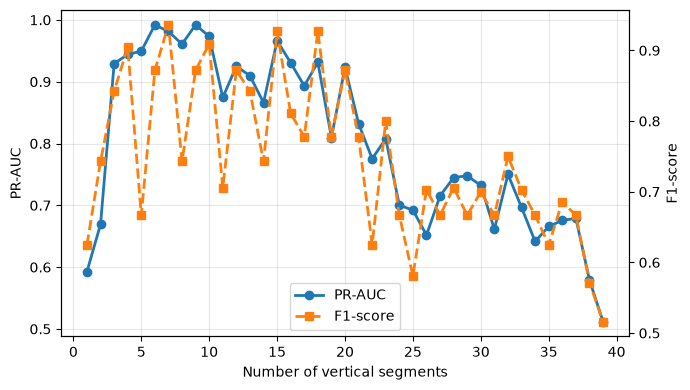

In [38]:
plot_df = (
    results_df
    .sort_values("segments")
    .drop_duplicates(subset=["segments"])
)

fig, ax1 = plt.subplots(figsize=(7, 4))

# PR-AUC
line1 = ax1.plot(
    plot_df["segments"],
    plot_df["pr_auc"],
    marker="o",
    linewidth=2,
    label="PR-AUC"
)

ax1.set_xlabel("Number of vertical segments")
ax1.set_ylabel("PR-AUC")
ax1.grid(alpha=0.3)

# F1-Score
ax2 = ax1.twinx()

line2 = ax2.plot(
    plot_df["segments"],
    plot_df["f1"],
    marker="s",
    linewidth=2,
    linestyle="--",
    color="tab:orange",
    label="F1-score"
)

ax2.set_ylabel("F1-score")

# Legend
lines = line1 + line2
labels = [l.get_label() for l in lines]

ax1.legend(lines, labels, loc="lower center")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "ver_sensitivity_combined.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [39]:
results_df.groupby("top_k")["pr_auc"].agg(["mean", "std"]) 

,mean,std
top_k,,
1,0.801909,0.136284
3,0.801909,0.136284
5,0.801909,0.136284
10,0.801909,0.136284


In [40]:
table_df = (
    results_df[
        ["segments", "top_k", "pr_auc", "f1"]
    ]
    .sort_values("pr_auc", ascending=False)
    .head(6)
)

print(table_df)


    segments  top_k    pr_auc        f1
32         9      1  0.991982  0.871795
33         9      3  0.991982  0.871795
34         9      5  0.991982  0.871795
35         9     10  0.991982  0.871795
20         6      1  0.991982  0.871795
21         6      3  0.991982  0.871795


# Save Results

In [41]:
results_df.to_csv(
    OUTPUT_DIR / "ver_sensitivity.csv",
    index=False
)

print("Saved:", OUTPUT_DIR / "ver_sensitivity.csv")


Saved: /home/sebastian/Dokumente/01_VSC/spectrogram-anomaly-ae/reports/ver_sensitivity.csv


In [42]:
pivot = results_df.pivot(
    index="segments",
    columns="top_k",
    values="pr_auc"
)

pivot.to_csv(
    OUTPUT_DIR / "ver_sensitivity_matrix.csv"
)

print(pivot)

top_k           1         3         5         10
segments                                        
1         0.592720  0.592720  0.592720  0.592720
2         0.669410  0.669410  0.669410  0.669410
3         0.929204  0.929204  0.929204  0.929204
4         0.944095  0.944095  0.944095  0.944095
5         0.949410  0.949410  0.949410  0.949410
6         0.991982  0.991982  0.991982  0.991982
7         0.981238  0.981238  0.981238  0.981238
8         0.960846  0.960846  0.960846  0.960846
9         0.991982  0.991982  0.991982  0.991982
10        0.973175  0.973175  0.973175  0.973175
11        0.874441  0.874441  0.874441  0.874441
12        0.924952  0.924952  0.924952  0.924952
13        0.909545  0.909545  0.909545  0.909545
14        0.866153  0.866153  0.866153  0.866153
15        0.966191  0.966191  0.966191  0.966191
16        0.930594  0.930594  0.930594  0.930594
17        0.893149  0.893149  0.893149  0.893149
18        0.931591  0.931591  0.931591  0.931591
19        0.809442  